# Deterministic-Mixture Importance Sampling

Estimates P(failure) using K per-parameter proposal distributions combined via the **balance heuristic** (Veach & Guibas 1995).

**IS variables:** `(z0, A, k, alpha)` only.  
Per-step noise terms `(ε_t, B_t)` are identical across all proposals and the nominal, so they cancel in the log-weight.

```
log w_i = log p_nom(z0_i, A_i, k_i, α_i) − log q_mix(z0_i, A_i, k_i, α_i)
log q_mix = log(1/K) + logsumexp_j( log q_j(x_i) )
```

All nominal parameters are imported from `nominal.py`.

In [31]:
# Cell 1 — Imports
import numpy as np
from scipy.stats import norm, uniform
from scipy.special import logsumexp
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from validation_utils import run_rollout, NominalSensorDistribution
from nominal import ROLLOUT_ARGS, SPECIFICATION, Z_TARGET

In [32]:
# Cell 2 — Unpack nominal parameters (all sourced from nominal.py)

NOM_MU_Z0    = ROLLOUT_ARGS["mu_z0"]
NOM_SIGMA_Z0 = ROLLOUT_ARGS["sigma_z0"]
NOM_SENSOR   = ROLLOUT_ARGS["sensor_args"]   # dict with mu_A, sigma_A, mu_k, …

N_STEPS = 2000
N_PER   = 100   # rollouts per proposal
N_JOBS  = -1    # -1 = use all available CPUs; set to 1 to disable parallelism

# Derived constants for alpha Gaussian proxy
_alpha_mid       = (NOM_SENSOR["alpha_min"] + NOM_SENSOR["alpha_max"]) / 2.0
_sigma_alpha_eff = (NOM_SENSOR["alpha_max"] - NOM_SENSOR["alpha_min"]) / 4.0

print("Nominal parameters (from nominal.py):")
print(f"  mu_z0={NOM_MU_Z0}, sigma_z0={NOM_SIGMA_Z0}")
print(f"  mu_A={NOM_SENSOR['mu_A']}, sigma_A={NOM_SENSOR['sigma_A']}")
print(f"  mu_k={NOM_SENSOR['mu_k']:.4f}, sigma_k={NOM_SENSOR['sigma_k']}")
print(f"  alpha_min={NOM_SENSOR['alpha_min']}, alpha_max={NOM_SENSOR['alpha_max']}")
print(f"  alpha_mid={_alpha_mid:.3f}, sigma_alpha_eff={_sigma_alpha_eff:.3f}")
print(f"Specification: {SPECIFICATION}")
print(f"Z_TARGET={Z_TARGET}, N_STEPS={N_STEPS}, N_PER={N_PER}, N_JOBS={N_JOBS}")

Nominal parameters (from nominal.py):
  mu_z0=0.5, sigma_z0=0.05
  mu_A=0.0, sigma_A=0.1
  mu_k=6.2832, sigma_k=0.5
  alpha_min=0.1, alpha_max=10.0
  alpha_mid=5.050, sigma_alpha_eff=2.475
Specification: {'z_min': 0.3, 'z_max': 0.7, 'pitch_min': -0.2617993877991494, 'pitch_max': 0.2617993877991494}
Z_TARGET=0.5, N_STEPS=2000, N_PER=100, N_JOBS=-1


In [33]:
# Cell 3 — Proposal definitions
#
# K = 5 proposals: 4 per-parameter proposals + the nominal itself.
# Including the nominal in the mixture stabilises the balance-heuristic
# denominator for samples that land near the nominal distribution.
#
# For q_A, q_k:   modify sensor_args passed to run_rollout; sensor samples naturally.
# For q_alpha:    sensor_args stay nominal; sample alpha from Gaussian in notebook
#                 and inject via sensor_params={"alpha": ...}.
# For q_z0:       sensor_args stay nominal; z0 drawn from shifted Gaussian.
# For q_nominal:  everything at nominal — rollouts serve as naive-MC baseline
#                 and contribute to the balance-heuristic denominator.

SCALE_C     = 3.0    # wider than nominal
DELTA_A     = 0.10   # shift A mean up  → larger wave disturbance
DELTA_K     = 0.0    # widen only (no clear failure direction for k)
DELTA_ALPHA = 1.0    # shift alpha mean up → deeper LiDAR penetration
DELTA_Z0    = -0.10  # shift z0 down → start closer to z_min


def _sensor_args_copy(**overrides):
    """Return a copy of the nominal sensor_args with given overrides."""
    d = dict(NOM_SENSOR)
    d.update(overrides)
    return d


# Each entry stores:
#   mu_z0, sigma_z0       — z0 sampling distribution
#   sensor_args           — passed to LiDARSensor (controls A, k, alpha sampling)
#   alpha_override        — None | (mu, sigma) for Gaussian alpha proposal
#   prop_*                — analytical distribution params used by balance heuristic
PROPOSALS = {
    "q_nominal": dict(
        mu_z0=NOM_MU_Z0,
        sigma_z0=NOM_SIGMA_Z0,
        sensor_args=NOM_SENSOR,
        alpha_override=None,
        prop_mu_A=NOM_SENSOR["mu_A"],
        prop_sigma_A=NOM_SENSOR["sigma_A"],
        prop_mu_k=NOM_SENSOR["mu_k"],
        prop_sigma_k=NOM_SENSOR["sigma_k"],
        prop_alpha_type="uniform",
    ),
    "q_A": dict(
        mu_z0=NOM_MU_Z0,
        sigma_z0=NOM_SIGMA_Z0,
        sensor_args=_sensor_args_copy(
            mu_A=NOM_SENSOR["mu_A"] + DELTA_A,
            sigma_A=SCALE_C * NOM_SENSOR["sigma_A"],
        ),
        alpha_override=None,
        prop_mu_A=NOM_SENSOR["mu_A"] + DELTA_A,
        prop_sigma_A=SCALE_C * NOM_SENSOR["sigma_A"],
        prop_mu_k=NOM_SENSOR["mu_k"],
        prop_sigma_k=NOM_SENSOR["sigma_k"],
        prop_alpha_type="uniform",
    ),
    "q_k": dict(
        mu_z0=NOM_MU_Z0,
        sigma_z0=NOM_SIGMA_Z0,
        sensor_args=_sensor_args_copy(
            mu_k=NOM_SENSOR["mu_k"] + DELTA_K,
            sigma_k=SCALE_C * NOM_SENSOR["sigma_k"],
        ),
        alpha_override=None,
        prop_mu_A=NOM_SENSOR["mu_A"],
        prop_sigma_A=NOM_SENSOR["sigma_A"],
        prop_mu_k=NOM_SENSOR["mu_k"] + DELTA_K,
        prop_sigma_k=SCALE_C * NOM_SENSOR["sigma_k"],
        prop_alpha_type="uniform",
    ),
    "q_alpha": dict(
        mu_z0=NOM_MU_Z0,
        sigma_z0=NOM_SIGMA_Z0,
        sensor_args=NOM_SENSOR,
        alpha_override=(_alpha_mid + DELTA_ALPHA, SCALE_C * _sigma_alpha_eff),
        prop_mu_A=NOM_SENSOR["mu_A"],
        prop_sigma_A=NOM_SENSOR["sigma_A"],
        prop_mu_k=NOM_SENSOR["mu_k"],
        prop_sigma_k=NOM_SENSOR["sigma_k"],
        prop_alpha_type="gaussian",
        prop_alpha_mu=_alpha_mid + DELTA_ALPHA,
        prop_alpha_sigma=SCALE_C * _sigma_alpha_eff,
    ),
    "q_z0": dict(
        mu_z0=NOM_MU_Z0 + DELTA_Z0,
        sigma_z0=SCALE_C * NOM_SIGMA_Z0,
        sensor_args=NOM_SENSOR,
        alpha_override=None,
        prop_mu_A=NOM_SENSOR["mu_A"],
        prop_sigma_A=NOM_SENSOR["sigma_A"],
        prop_mu_k=NOM_SENSOR["mu_k"],
        prop_sigma_k=NOM_SENSOR["sigma_k"],
        prop_alpha_type="uniform",
    ),
}

K = len(PROPOSALS)
print(f"K={K} proposals, N_PER={N_PER} → N={K * N_PER} total rollouts")
for name, p in PROPOSALS.items():
    atype = p["prop_alpha_type"]
    astr  = (f"N({p['prop_alpha_mu']:.2f}, {p['prop_alpha_sigma']:.2f})"
             if atype == "gaussian" else "Uniform(nominal)")
    print(f"  {name}: mu_z0={p['mu_z0']:.3f}±{p['sigma_z0']:.3f}, "
          f"mu_A={p['prop_mu_A']:.3f}±{p['prop_sigma_A']:.3f}, "
          f"mu_k={p['prop_mu_k']:.3f}±{p['prop_sigma_k']:.3f}, "
          f"alpha={astr}")

K=5 proposals, N_PER=100 → N=500 total rollouts
  q_nominal: mu_z0=0.500±0.050, mu_A=0.000±0.100, mu_k=6.283±0.500, alpha=Uniform(nominal)
  q_A: mu_z0=0.500±0.050, mu_A=0.100±0.300, mu_k=6.283±0.500, alpha=Uniform(nominal)
  q_k: mu_z0=0.500±0.050, mu_A=0.000±0.100, mu_k=6.283±1.500, alpha=Uniform(nominal)
  q_alpha: mu_z0=0.500±0.050, mu_A=0.000±0.100, mu_k=6.283±0.500, alpha=N(6.05, 7.43)
  q_z0: mu_z0=0.400±0.150, mu_A=0.000±0.100, mu_k=6.283±0.500, alpha=Uniform(nominal)


In [34]:
# Cell 4 — Run rollouts in parallel across all proposals
#
# All 500 rollouts are independent, so we dispatch them together.
# Random inputs (z0, alpha overrides) are generated in the main process
# first — this preserves the exact same draws as the sequential version.
#
# Requires joblib >= 1.3 for return_as="generator" (real-time tqdm).
# Install if needed:  pip install -U joblib

from joblib import Parallel, delayed


def _run_one(j, name, i, z0, sensor_params, sensor_args,
             z_target, n_steps, n_per, specification):
    """Single rollout worker. All inputs are explicit — no notebook globals."""
    from validation_utils import run_rollout   # re-import is safe in worker processes
    result = run_rollout(
        sensor_params=sensor_params,
        z0=z0,
        z_target=z_target,
        n_steps=n_steps,
        seed=j * n_per + i,
        sensor_args=sensor_args,
        specification=specification,
        ground_effect_enabled=True,
        enable_lateral_damper=True,
    )
    return dict(
        proposal=name,
        proposal_idx=j,
        z0=z0,
        A=result["sensor_A"],
        k=result["sensor_k"],
        alpha=result["sensor_alpha"],
        rho=result["rho"],
        failed=result["is_failure"],
    )


# ── Pre-generate random inputs in main process (reproducible) ────────────────
job_args = []
for j, (name, prop) in enumerate(PROPOSALS.items()):
    rng = np.random.default_rng(j * 1000)
    for i in range(N_PER):
        z0 = float(rng.normal(prop["mu_z0"], prop["sigma_z0"]))
        sensor_params = {}
        if prop["alpha_override"] is not None:
            alpha_mu, alpha_sigma = prop["alpha_override"]
            sensor_params["alpha"] = float(rng.normal(alpha_mu, alpha_sigma))
        job_args.append(dict(
            j=j, name=name, i=i,
            z0=z0, sensor_params=sensor_params,
            sensor_args=prop["sensor_args"],
        ))

print(f"Dispatching {len(job_args)} rollouts across {N_JOBS} workers …")

# ── Parallel dispatch (real-time progress bar via generator) ─────────────────
_gen = Parallel(n_jobs=N_JOBS, return_as="generator")(
    delayed(_run_one)(
        j=a["j"], name=a["name"], i=a["i"],
        z0=a["z0"], sensor_params=a["sensor_params"],
        sensor_args=a["sensor_args"],
        z_target=Z_TARGET, n_steps=N_STEPS, n_per=N_PER,
        specification=SPECIFICATION,
    )
    for a in job_args
)
records = list(tqdm(_gen, total=len(job_args), desc="rollouts"))

# ── Summary ───────────────────────────────────────────────────────────────────
N_TOTAL       = len(records)
total_failures = sum(r["failed"] for r in records)
print(f"\nTotal rollouts: {N_TOTAL},  Total failures: {total_failures} "
      f"({100*total_failures/N_TOTAL:.2f}%)")

for name in PROPOSALS:
    prop_recs = [r for r in records if r["proposal"] == name]
    n_fail    = sum(r["failed"] for r in prop_recs)
    print(f"  {name}: {n_fail}/{len(prop_recs)} ({100*n_fail/len(prop_recs):.1f}%)")

nom_records   = [r for r in records if r["proposal"] == "q_nominal"]
nom_fail_rate = np.mean([r["failed"] for r in nom_records])
print(f"\nNaive MC (q_nominal only): {sum(r['failed'] for r in nom_records)}/{len(nom_records)} "
      f"= {100*nom_fail_rate:.2f}%")

Dispatching 500 rollouts across -1 workers …


rollouts:   0%|          | 0/500 [00:00<?, ?it/s]


Total rollouts: 500,  Total failures: 78 (15.60%)
  q_nominal: 2/100 (2.0%)
  q_A: 13/100 (13.0%)
  q_k: 3/100 (3.0%)
  q_alpha: 28/100 (28.0%)
  q_z0: 32/100 (32.0%)

Naive MC (q_nominal only): 2/100 = 2.00%


In [35]:
# Cell 5 — Balance Heuristic IS Weights

def log_nominal_density(z0, A, k, alpha):
    """
    log p_nom(z0, A, k, alpha)
      = N(z0; mu_z0_nom, sigma_z0_nom)
      + N(A;  mu_A_nom,  sigma_A_nom)
      + N(k;  mu_k_nom,  sigma_k_nom)
      + U(alpha; alpha_min, alpha_max)   [= -inf outside support]
    """
    log_z0    = norm.logpdf(z0,    NOM_MU_Z0,              NOM_SIGMA_Z0)
    log_A     = norm.logpdf(A,     NOM_SENSOR["mu_A"],     NOM_SENSOR["sigma_A"])
    log_k     = norm.logpdf(k,     NOM_SENSOR["mu_k"],     NOM_SENSOR["sigma_k"])
    log_alpha = uniform.logpdf(
        alpha,
        NOM_SENSOR["alpha_min"],
        NOM_SENSOR["alpha_max"] - NOM_SENSOR["alpha_min"],
    )
    return float(log_z0 + log_A + log_k + log_alpha)


def log_proposal_density(prop, z0, A, k, alpha):
    """
    log q_j(z0, A, k, alpha) for proposal dict `prop`.
    Only the changed parameter uses the proposal distribution; others use nominal.
    """
    log_z0 = norm.logpdf(z0, prop["mu_z0"],     prop["sigma_z0"])
    log_A  = norm.logpdf(A,  prop["prop_mu_A"],  prop["prop_sigma_A"])
    log_k  = norm.logpdf(k,  prop["prop_mu_k"],  prop["prop_sigma_k"])

    if prop["prop_alpha_type"] == "gaussian":
        log_alpha = norm.logpdf(alpha, prop["prop_alpha_mu"], prop["prop_alpha_sigma"])
    else:  # "uniform" — same as nominal
        log_alpha = uniform.logpdf(
            alpha,
            NOM_SENSOR["alpha_min"],
            NOM_SENSOR["alpha_max"] - NOM_SENSOR["alpha_min"],
        )

    return float(log_z0 + log_A + log_k + log_alpha)


proposal_list = list(PROPOSALS.values())

log_w_all = np.empty(N_TOTAL)

for idx, rec in enumerate(records):
    z0, A, k, alpha = rec["z0"], rec["A"], rec["k"], rec["alpha"]

    log_p  = log_nominal_density(z0, A, k, alpha)
    log_qs = np.array([log_proposal_density(p, z0, A, k, alpha) for p in proposal_list])

    # Balance heuristic mixture: (1/K) * Σ_j q_j(x)
    log_q_mix = -np.log(K) + logsumexp(log_qs)

    log_w_all[idx] = log_p - log_q_mix
    rec["log_w"]   = float(log_w_all[idx])

print("Log-weight stats (all proposals combined):")
print(f"  mean  = {log_w_all[np.isfinite(log_w_all)].mean():.3f}")
print(f"  std   = {log_w_all[np.isfinite(log_w_all)].std():.3f}")
print(f"  range = [{log_w_all[np.isfinite(log_w_all)].min():.2f}, "
      f"{log_w_all[np.isfinite(log_w_all)].max():.2f}]")

n_zero_w = int(np.sum(~np.isfinite(log_w_all)))
print(f"  Zero-weight samples (alpha outside nominal support): "
      f"{n_zero_w}/{N_TOTAL} ({100*n_zero_w/N_TOTAL:.1f}%)")

Log-weight stats (all proposals combined):
  mean  = -2.175
  std   = 5.965
  range = [-42.95, 0.77]
  Zero-weight samples (alpha outside nominal support): 51/500 (10.2%)


In [36]:
# Cell 6 — Failure Probability Estimates

failed_all  = np.array([r["failed"] for r in records], dtype=float)
finite_mask = np.isfinite(log_w_all)
lw_fin      = log_w_all[finite_mask]
fail_fin    = failed_all[finite_mask]
N_finite    = int(finite_mask.sum())

# Unnormalised IS
w       = np.exp(lw_fin)
p_unnorm = float(np.mean(w * fail_fin))

# Self-Normalised IS (SNIS)
log_sum_w   = logsumexp(lw_fin)
w_tilde     = np.exp(lw_fin - log_sum_w)
p_sn        = float(np.dot(w_tilde, fail_fin))

# ESS
ess      = float(np.exp(2 * log_sum_w - logsumexp(2 * lw_fin)))
ess_frac = ess / N_finite

# IS identity check (should ≈ 1)
is_identity = float(np.mean(w))

# Naive MC from nominal rollouts
nom_mask      = np.array([r["proposal"] == "q_nominal" for r in records])
p_naive_mc    = float(np.mean(failed_all[nom_mask]))
n_nom_fail    = int(failed_all[nom_mask].sum())
n_nom         = int(nom_mask.sum())

print("=" * 60)
print("Failure Probability Estimates")
print("=" * 60)
print(f"  P̂_naive_MC  (nominal rollouts only) = {p_naive_mc:.4e}  "
      f"[{n_nom_fail}/{n_nom} failures]")
print(f"  P̂_unnorm   (unnormalised IS)        = {p_unnorm:.4e}")
print(f"  P̂_SN       (self-normalised IS)     = {p_sn:.4e}")
print(f"  ESS = {ess:.1f} / {N_finite}  (ESS/N = {100*ess_frac:.1f}%)")
print(f"  IS identity check: mean(w) = {is_identity:.4f}  [target: 1.0]")
print()
print("Per-proposal failure counts:")
for name in PROPOSALS:
    mask   = np.array([r["proposal"] == name for r in records])
    n_fail = int(failed_all[mask].sum())
    n_tot  = int(mask.sum())
    label  = " ← naive MC baseline" if name == "q_nominal" else ""
    print(f"  {name}: {n_fail}/{n_tot} ({100*n_fail/n_tot:.1f}%){label}")

Failure Probability Estimates
  P̂_naive_MC  (nominal rollouts only) = 2.0000e-02  [2/100 failures]
  P̂_unnorm   (unnormalised IS)        = 2.8372e-02
  P̂_SN       (self-normalised IS)     = 2.5204e-02
  ESS = 305.7 / 449  (ESS/N = 68.1%)
  IS identity check: mean(w) = 1.1257  [target: 1.0]

Per-proposal failure counts:
  q_nominal: 2/100 (2.0%) ← naive MC baseline
  q_A: 13/100 (13.0%)
  q_k: 3/100 (3.0%)
  q_alpha: 28/100 (28.0%)
  q_z0: 32/100 (32.0%)


In [37]:
# Cell 7 — Per-proposal ESS

print("Per-proposal ESS breakdown:")
for name in PROPOSALS:
    mask    = np.array([r["proposal"] == name for r in records])
    lw_p    = log_w_all[mask]
    lw_p_f  = lw_p[np.isfinite(lw_p)]
    if len(lw_p_f) > 1:
        ess_p = float(np.exp(2 * logsumexp(lw_p_f) - logsumexp(2 * lw_p_f)))
    else:
        ess_p = 0.0
    print(f"  {name}: ESS={ess_p:.1f}/{N_PER} ({100*ess_p/N_PER:.1f}%)")

print(f"\nCombined mixture ESS: {ess:.1f}/{N_finite} ({100*ess_frac:.1f}%)")

Per-proposal ESS breakdown:
  q_nominal: ESS=94.7/100 (94.7%)
  q_A: ESS=60.1/100 (60.1%)
  q_k: ESS=56.4/100 (56.4%)
  q_alpha: ESS=45.7/100 (45.7%)
  q_z0: ESS=50.2/100 (50.2%)

Combined mixture ESS: 305.7/449 (68.1%)


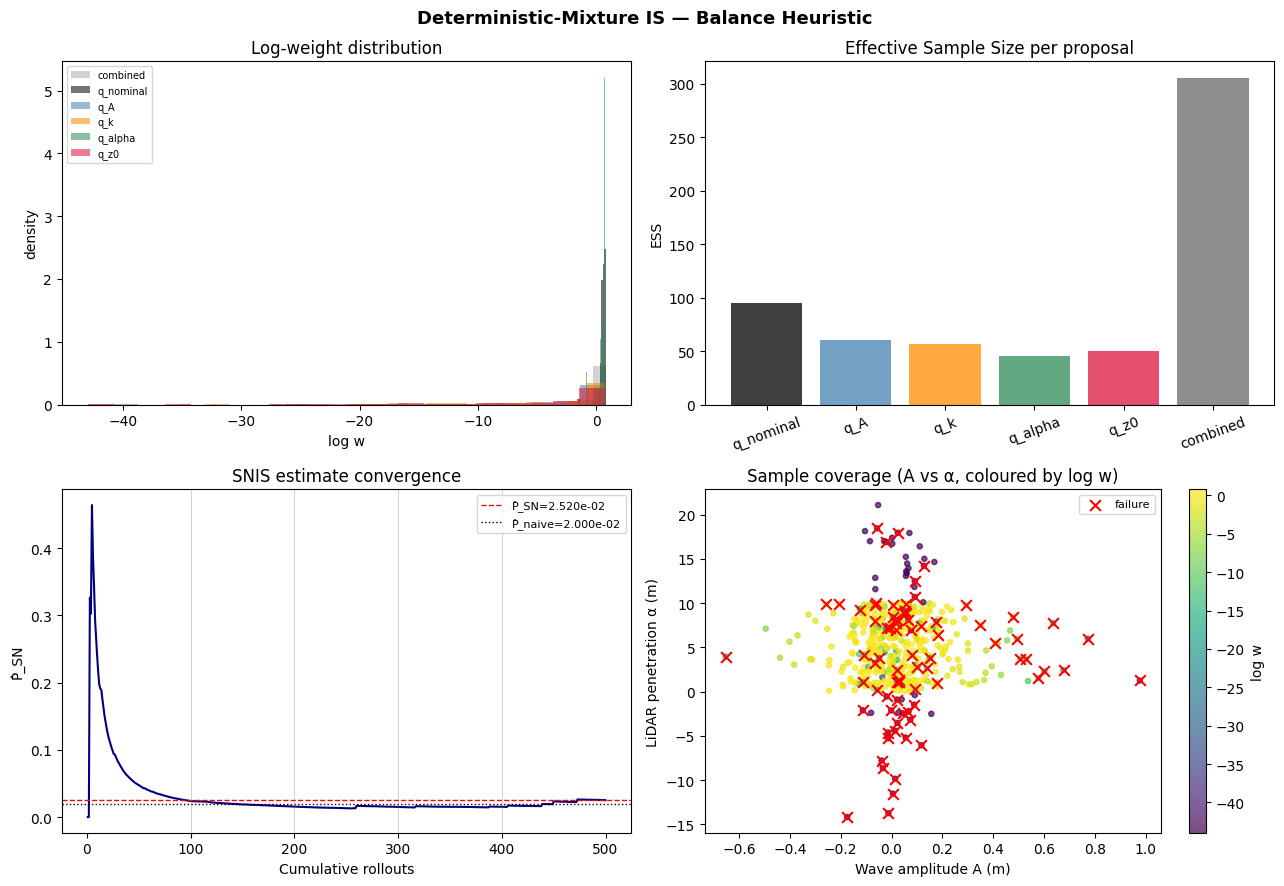

Saved plots/dm_is_diagnostics.png


In [38]:
# Cell 8 — Diagnostics & Visualisations

prop_names  = list(PROPOSALS.keys())
prop_colors = ["black", "steelblue", "darkorange", "seagreen", "crimson"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ── Plot 1: Log-weight histogram (per proposal + combined) ──────────────────
ax = axes[0, 0]
fin = np.isfinite(log_w_all)
ax.hist(log_w_all[fin], bins=40, color="grey", alpha=0.35,
        label="combined", density=True)
for name, col in zip(prop_names, prop_colors):
    mask = np.array([r["proposal"] == name for r in records])
    lw   = log_w_all[mask & fin]
    ax.hist(lw, bins=20, color=col, alpha=0.55, label=name, density=True)
ax.set_xlabel("log w")
ax.set_ylabel("density")
ax.set_title("Log-weight distribution")
ax.legend(fontsize=7)

# ── Plot 2: ESS per proposal + combined ─────────────────────────────────────
ax = axes[0, 1]
ess_vals = []
for name in prop_names:
    mask   = np.array([r["proposal"] == name for r in records])
    lw_p   = log_w_all[mask]
    lw_p_f = lw_p[np.isfinite(lw_p)]
    ess_p  = (float(np.exp(2 * logsumexp(lw_p_f) - logsumexp(2 * lw_p_f)))
              if len(lw_p_f) > 1 else 0.0)
    ess_vals.append(ess_p)
bar_labels  = prop_names + ["combined"]
bar_heights = ess_vals + [ess]
bar_colors  = prop_colors + ["dimgrey"]
ax.bar(bar_labels, bar_heights, color=bar_colors, alpha=0.75)
ax.set_ylabel("ESS")
ax.set_title("Effective Sample Size per proposal")
ax.tick_params(axis="x", rotation=20)

# ── Plot 3: Convergence of P̂_SN vs cumulative rollouts ────────────────────
ax = axes[1, 0]
p_sn_curve = []
for n in range(1, N_TOTAL + 1):
    lw_n = log_w_all[:n]
    f_n  = failed_all[:n]
    msk  = np.isfinite(lw_n)
    if msk.sum() == 0 or f_n[msk].sum() == 0:
        p_sn_curve.append(0.0)
        continue
    lsw = logsumexp(lw_n[msk])
    wt  = np.exp(lw_n[msk] - lsw)
    p_sn_curve.append(float(np.dot(wt, f_n[msk])))
ax.plot(range(1, N_TOTAL + 1), p_sn_curve, color="navy", linewidth=1.5)
ax.axhline(p_sn,       linestyle="--", color="red",   linewidth=1,
           label=f"P̂_SN={p_sn:.3e}")
ax.axhline(p_naive_mc, linestyle=":",  color="black", linewidth=1,
           label=f"P̂_naive={p_naive_mc:.3e}")
# Mark proposal boundaries
for bnd in range(N_PER, N_TOTAL, N_PER):
    ax.axvline(bnd, color="grey", linewidth=0.5, alpha=0.5)
ax.set_xlabel("Cumulative rollouts")
ax.set_ylabel("P̂_SN")
ax.set_title("SNIS estimate convergence")
ax.legend(fontsize=8)

# ── Plot 4: Scatter (A vs alpha), colour = log_w, mark failures ─────────────
ax = axes[1, 1]
A_arr     = np.array([r["A"]     for r in records])
alpha_arr = np.array([r["alpha"] for r in records])
lw_plot   = log_w_all.copy()
lw_plot[~np.isfinite(lw_plot)] = np.nanmin(lw_plot[np.isfinite(lw_plot)]) - 1
sc = ax.scatter(A_arr, alpha_arr, c=lw_plot, cmap="viridis", s=14, alpha=0.7)
fail_mask = np.array([r["failed"] for r in records])
ax.scatter(A_arr[fail_mask], alpha_arr[fail_mask],
           marker="x", s=60, color="red", linewidths=1.5, label="failure")
plt.colorbar(sc, ax=ax, label="log w")
ax.set_xlabel("Wave amplitude A (m)")
ax.set_ylabel("LiDAR penetration α (m)")
ax.set_title("Sample coverage (A vs α, coloured by log w)")
ax.legend(fontsize=8)

fig.suptitle("Deterministic-Mixture IS — Balance Heuristic", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("plots/dm_is_diagnostics.png", dpi=150)
plt.show()
print("Saved plots/dm_is_diagnostics.png")

In [39]:
# Cell 9 — Most important failure + final summary

fail_indices = [i for i, r in enumerate(records) if r["failed"]]
fin_indices  = [i for i in fail_indices if np.isfinite(log_w_all[i])]

if fin_indices:
    best_idx = max(fin_indices, key=lambda i: log_w_all[i])
    bf = records[best_idx]
    print("Most important failure (highest IS weight among failed rollouts):")
    print(f"  proposal = {bf['proposal']}")
    print(f"  z0       = {bf['z0']:.4f} m")
    print(f"  A        = {bf['A']:.4f} m")
    print(f"  k        = {bf['k']:.4f} rad/m")
    print(f"  alpha    = {bf['alpha']:.4f} m")
    print(f"  rho      = {bf['rho']:.4f}  (< 0 = failure)")
    print(f"  log_w    = {bf['log_w']:.3f}  →  w = {np.exp(bf['log_w']):.4e}")
    print(f"  w̃_i      = {np.exp(bf['log_w'] - log_sum_w):.4e}  (normalised)")
else:
    print("No finite-weight failures observed. Consider widening proposals or increasing N_PER.")

print()
print("=" * 60)
print("Final Summary")
print("=" * 60)
print(f"  N_total       = {N_TOTAL}  ({K} proposals × {N_PER})")
print(f"  Failures      = {int(failed_all.sum())}  (naive rate = {100*failed_all.mean():.2f}%)")
print(f"  P̂_naive_MC    = {p_naive_mc:.4e}  (nominal rollouts only)")
print(f"  P̂_unnorm      = {p_unnorm:.4e}")
print(f"  P̂_SN          = {p_sn:.4e}")
print(f"  ESS           = {ess:.1f} / {N_finite}  ({100*ess_frac:.1f}%)")
print(f"  IS identity   = {is_identity:.4f}  [target: 1.0]")
print(f"  Zero-w count  = {n_zero_w}  ({100*n_zero_w/N_TOTAL:.1f}%)")

Most important failure (highest IS weight among failed rollouts):
  proposal = q_nominal
  z0       = 0.5320 m
  A        = 0.0189 m
  k        = 6.0218 rad/m
  alpha    = 8.1608 m
  rho      = -0.0014  (< 0 = failure)
  log_w    = 0.696  →  w = 2.0063e+00
  w̃_i      = 3.9693e-03  (normalised)

Final Summary
  N_total       = 500  (5 proposals × 100)
  Failures      = 78  (naive rate = 15.60%)
  P̂_naive_MC    = 2.0000e-02  (nominal rollouts only)
  P̂_unnorm      = 2.8372e-02
  P̂_SN          = 2.5204e-02
  ESS           = 305.7 / 449  (68.1%)
  IS identity   = 1.1257  [target: 1.0]
  Zero-w count  = 51  (10.2%)


In [ ]:
# Cell 10 — Save results to .npz for sharing
#
# Loads cleanly on any machine with numpy:
#   data = np.load("dm_is_results.npz", allow_pickle=False)
#   records_loaded = [{k: data[k][i] for k in data.files if k != "log_w_all"}
#                     for i in range(len(data["z0"]))]

np.savez(
    "dm_is_results.npz",
    # per-rollout scalar arrays (one entry per rollout, length = N_TOTAL)
    proposal       = np.array([r["proposal"]      for r in records]),
    proposal_idx   = np.array([r["proposal_idx"]  for r in records], dtype=np.int32),
    z0             = np.array([r["z0"]            for r in records]),
    A              = np.array([r["A"]             for r in records]),
    k              = np.array([r["k"]             for r in records]),
    alpha          = np.array([r["alpha"]         for r in records]),
    rho            = np.array([r["rho"]           for r in records]),
    failed         = np.array([r["failed"]        for r in records], dtype=bool),
    log_w          = log_w_all,
    # metadata scalars (shape () arrays — access as data["N_TOTAL"].item())
    N_TOTAL        = np.array(N_TOTAL),
    N_PER          = np.array(N_PER),
    K              = np.array(K),
    Z_TARGET       = np.array(Z_TARGET),
    N_STEPS        = np.array(N_STEPS),
)
print("Saved dm_is_results.npz")
print(f"  Arrays: proposal, proposal_idx, z0, A, k, alpha, rho, failed, log_w")
print(f"  Metadata: N_TOTAL={N_TOTAL}, N_PER={N_PER}, K={K}, "
      f"Z_TARGET={Z_TARGET}, N_STEPS={N_STEPS}")